<a href="https://colab.research.google.com/github/aurorapiccione/bluesky-ai-network-analysis/blob/main/TikTok_Travel_Network_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q networkx python-louvain pandas matplotlib plotly

In [2]:
import json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain

from collections import Counter

In [3]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

with open(filename, "r", encoding="utf-8") as file:
    data = json.load(file)

print("File caricato:", filename)
print("Numero di video:", len(data))

Saving dataset_tiktok-scraper_2026-08-06_15-22-53-082.json to dataset_tiktok-scraper_2026-08-06_15-22-53-082.json
File caricato: dataset_tiktok-scraper_2026-08-06_15-22-53-082.json
Numero di video: 240


In [4]:
rows = []

for video in data:

    author = video.get("authorMeta") or {}
    location = video.get("locationMeta") or {}

    hashtags = [
        hashtag.get("name", "").lower().strip()
        for hashtag in video.get("hashtags", [])
        if hashtag.get("name")
    ]

    rows.append({
        "video_id": video.get("id"),
        "creator": author.get("name"),
        "nickname": author.get("nickName"),
        "followers": author.get("fans", 0),
        "following": author.get("following", 0),
        "profile_likes": author.get("heart", 0),
        "likes": video.get("diggCount", 0),
        "comments": video.get("commentCount", 0),
        "shares": video.get("shareCount", 0),
        "saves": video.get("collectCount", 0),
        "views": video.get("playCount", 0),
        "hashtags": hashtags,
        "language": video.get("textLanguage"),
        "date": video.get("createTimeISO"),
        "city": location.get("city"),
        "location_name": location.get("locationName"),
        "text": video.get("text"),
        "video_url": video.get("webVideoUrl")
    })

df = pd.DataFrame(rows)

df.head()

,video_id,creator,nickname,followers,following,profile_likes,likes,comments,shares,saves,views,hashtags,language,date,city,location_name,text,video_url
0,7652490807697591566,globalwlena,Lena|Travel•Dining•Experiences,3572,185,410600,711,15,213,593,31200,"[italy, amalficoast, eurosummer, traveladvisor]",en,2026-06-17T22:13:16.000Z,Salerno,Borgo Santandrea Hotel,Want to feel as if you’re staying in a beautif...,https://www.tiktok.com/@globalwlena/video/7652...
1,7632820211099667735,dejashu,Shu Lin,36800,2314,1500000,5413,33,1297,4829,88100,"[rome, italy, solotravel, arthistory, rometravel]",en,2026-04-25T22:00:49.000Z,Rome,Doria Pamphilj Gallery,Truly a hidden gem in Rome that tourists compl...,https://www.tiktok.com/@dejashu/video/76328202...
2,7667734865097411871,gallivanting_girly,Gallivanting_girly,1093,9,33400,335,9,92,51,7499,"[italy, italia, italiansummer, italytrip, travel]",en,2026-07-29T00:07:40.000Z,Salerno,Amalfi Coast,This is your sign to book that trip to Italy ✈...,https://www.tiktok.com/@gallivanting_girly/vid...
3,7556626297980587295,hdyht33,hdyht33,149300,0,1200000,1179,44,594,274,33100,"[amalficoast, italy, explore, knowledge]",en,2025-10-02T14:09:56.000Z,East Los Angeles,Los Angeles California Temple,The Most Beautiful Place in Italy - Amalfi Coa...,https://www.tiktok.com/@hdyht33/video/75566262...
4,7566610662986616095,openmyworld,Yami,54800,44,10900000,28600,160,8421,13694,653500,"[grottapalazzese, italytravel, travelgoals, hi...",en,2025-10-29T11:54:03.000Z,Bari,Grotta Palazzese,"Dinner inside a cliff, overlooking the Adriati...",https://www.tiktok.com/@openmyworld/video/7566...


In [52]:
df[["creator", "followers", "views", "hashtags"]].head(8)

,creator,followers,views,hashtags
0,globalwlena,3572,31200,"[italy, amalficoast, eurosummer, traveladvisor]"
1,dejashu,36800,88100,"[rome, italy, solotravel, arthistory, rometravel]"
2,gallivanting_girly,1093,7499,"[italy, italia, italiansummer, italytrip, travel]"
3,hdyht33,149300,33100,"[amalficoast, italy, explore, knowledge]"
4,openmyworld,54800,653500,"[grottapalazzese, italytravel, travelgoals, hi..."
5,rayssadaniela____,3691,573800,"[italy, costaamalfitana, travel]"
6,minhpowell,4054,162500,"[rometravel, hotelstay, romehotels, italytrave..."
7,lizvaugin,81600,59900,"[tuscany, tuscanyitaly, italytravel, europeans..."


In [5]:
print("Numero di righe:", len(df))
print("Numero di colonne:", len(df.columns))
print("Creator unici:", df["creator"].nunique())

df.info()

Numero di righe: 240
Numero di colonne: 18
Creator unici: 181
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   video_id       240 non-null    object
 1   creator        240 non-null    object
 2   nickname       240 non-null    object
 3   followers      240 non-null    int64 
 4   following      240 non-null    int64 
 5   profile_likes  240 non-null    int64 
 6   likes          240 non-null    int64 
 7   comments       240 non-null    int64 
 8   shares         240 non-null    int64 
 9   saves          240 non-null    int64 
 10  views          240 non-null    int64 
 11  hashtags       240 non-null    object
 12  language       240 non-null    object
 13  date           240 non-null    object
 14  city           130 non-null    object
 15  location_name  130 non-null    object
 16  text           240 non-null    object
 17  video_url  

In [6]:
df.isnull().sum()

,0
video_id,0
creator,0
nickname,0
followers,0
following,0
profile_likes,0
likes,0
comments,0
shares,0
saves,0


In [7]:
df = df.dropna(subset=["creator"]).copy()

df["creator"] = df["creator"].astype(str).str.lower().str.strip()

print("Video dopo la pulizia:", len(df))
print("Creator unici dopo la pulizia:", df["creator"].nunique())

Video dopo la pulizia: 240
Creator unici dopo la pulizia: 181


In [8]:
all_hashtags = []

for hashtag_list in df["hashtags"]:
    all_hashtags.extend(hashtag_list)

hashtag_counts = Counter(all_hashtags)

hashtag_counts.most_common(20)

[('italy', 65),
 ('travel', 43),
 ('italytravel', 39),
 ('travelblogger', 32),
 ('traveltok', 23),
 ('amalficoast', 19),
 ('travelcreator', 16),
 ('rome', 14),
 ('solotravel', 11),
 ('italia', 11),
 ('italytrip', 11),
 ('travelinspo', 10),
 ('traveltiktok', 10),
 ('fyp', 10),
 ('tiktoktravel', 9),
 ('lakecomo', 9),
 ('viaggiare', 9),
 ('eurosummer', 8),
 ('rometravel', 8),
 ('visititaly', 8)]

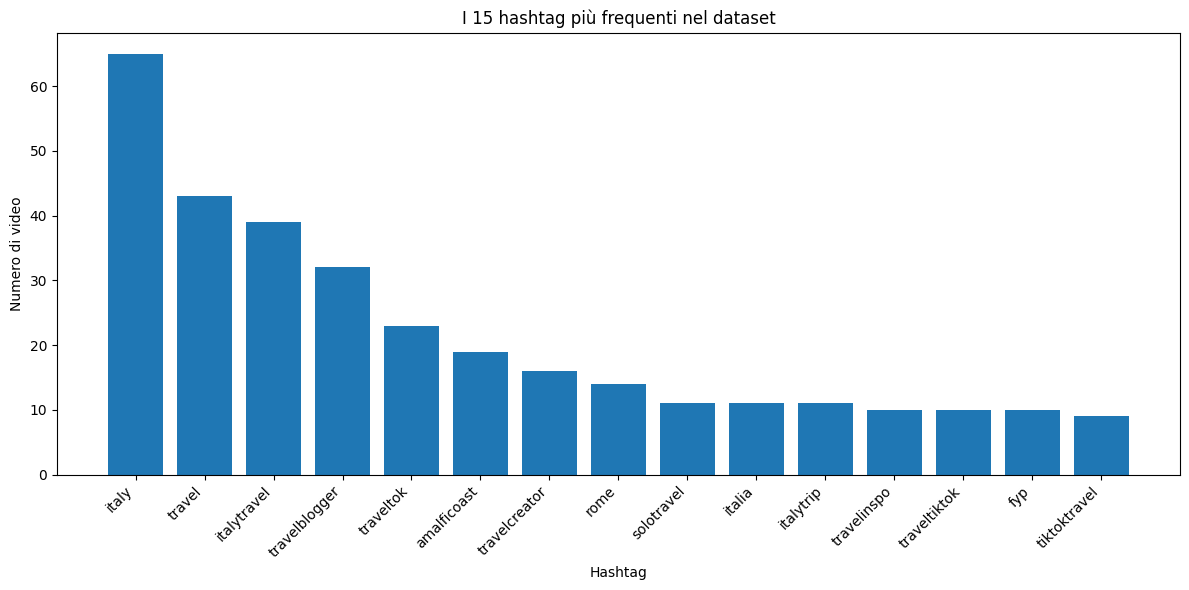

In [9]:
top_hashtags = hashtag_counts.most_common(15)

hashtag_names = [item[0] for item in top_hashtags]
hashtag_frequencies = [item[1] for item in top_hashtags]

plt.figure(figsize=(12, 6))
plt.bar(hashtag_names, hashtag_frequencies)

plt.title("I 15 hashtag più frequenti nel dataset")
plt.xlabel("Hashtag")
plt.ylabel("Numero di video")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [10]:
excluded_hashtags = {
    "travel",
    "traveltok",
    "tiktoktravel",
    "travelvideo",
    "travelinspo",
    "travelgram",
    "wanderlust",
    "italy",
    "italia",
    "italytravel",
    "travelitalia",
    "visititaly",
    "italytrip",
    "viaggi",
    "viaggio",
    "vacanze",
    "vacanza",
    "fyp",
    "foryou",
    "foryoupage",
    "viral",
    "explore",
    "perte",
    "neiperte"
}

print("Hashtag esclusi:", len(excluded_hashtags))

Hashtag esclusi: 24


In [11]:
def clean_hashtags(hashtags):

    if not isinstance(hashtags, list):
        return []

    cleaned = {
        str(hashtag)
        .lower()
        .strip()
        .replace("#", "")
        for hashtag in hashtags
        if hashtag
    }

    cleaned = cleaned - excluded_hashtags

    return sorted(cleaned)


df["clean_hashtags"] = df["hashtags"].apply(clean_hashtags)

df[["creator", "hashtags", "clean_hashtags"]].head()

,creator,hashtags,clean_hashtags
0,globalwlena,"[italy, amalficoast, eurosummer, traveladvisor]","[amalficoast, eurosummer, traveladvisor]"
1,dejashu,"[rome, italy, solotravel, arthistory, rometravel]","[arthistory, rome, rometravel, solotravel]"
2,gallivanting_girly,"[italy, italia, italiansummer, italytrip, travel]",[italiansummer]
3,hdyht33,"[amalficoast, italy, explore, knowledge]","[amalficoast, knowledge]"
4,openmyworld,"[grottapalazzese, italytravel, travelgoals, hi...","[beautifulplaces, bucketlistplaces, caverestau..."


In [12]:
clean_hashtags_list = []

for hashtag_list in df["clean_hashtags"]:
    clean_hashtags_list.extend(hashtag_list)

clean_hashtag_counts = Counter(clean_hashtags_list)

clean_hashtag_counts.most_common(20)

[('travelblogger', 32),
 ('amalficoast', 19),
 ('travelcreator', 16),
 ('rome', 14),
 ('solotravel', 11),
 ('traveltiktok', 10),
 ('lakecomo', 9),
 ('viaggiare', 9),
 ('eurosummer', 8),
 ('rometravel', 8),
 ('creatorsearchinsights', 8),
 ('vacation', 8),
 ('traveltips', 8),
 ('italiansummer', 7),
 ('europetravel', 7),
 ('travelphotography', 7),
 ('italy🇮🇹', 7),
 ('luxurytravel', 6),
 ('travelgoals', 6),
 ('tuscany', 6)]

In [13]:
creator_data = (
    df.groupby("creator")
    .agg(
        nickname=("nickname", "first"),
        followers=("followers", "max"),
        following=("following", "max"),
        total_views=("views", "sum"),
        total_likes=("likes", "sum"),
        total_comments=("comments", "sum"),
        total_shares=("shares", "sum"),
        total_saves=("saves", "sum"),
        number_of_videos=("video_id", "nunique"),
        hashtags=(
            "clean_hashtags",
            lambda lists: sorted({
                hashtag
                for hashtag_list in lists
                for hashtag in hashtag_list
            })
        )
    )
    .reset_index()
)

creator_data.head()

,creator,nickname,followers,following,total_views,total_likes,total_comments,total_shares,total_saves,number_of_videos,hashtags
0,21annak21,Ania,76,513,1086,40,0,0,1,1,"[sciacca, vacanzeitalia]"
1,__kasun_0_sanjula__,Travel S A N J U 👣❤️🌿🚶‍♂️,4501,2770,260200,24100,334,1063,1858,1,"[clouds, fypシ゚, naturevibes, srilanka, travelb..."
2,_mibir,I,2,0,1677,108,0,3,8,1,"[colosseum, pantheon, rome, trevifountain, vet..."
3,ajtravel_adventures,AJ Travel Adventures,1467,83,69600,1980,41,466,116,1,"[coupletok, coupletravel, cruisetheworld, crui..."
4,aktravelss,AKTRAVELS ✈️ 🌍,337700,33,6429,513,5,51,58,1,"[travelblogger, traveldiaries, travelgoals]"


In [14]:
print("Numero di creator:", len(creator_data))

creator_data[
    [
        "creator",
        "followers",
        "number_of_videos",
        "total_views",
        "hashtags"
    ]
].head(10)

Numero di creator: 181


,creator,followers,number_of_videos,total_views,hashtags
0,21annak21,76,1,1086,"[sciacca, vacanzeitalia]"
1,__kasun_0_sanjula__,4501,1,260200,"[clouds, fypシ゚, naturevibes, srilanka, travelb..."
2,_mibir,2,1,1677,"[colosseum, pantheon, rome, trevifountain, vet..."
3,ajtravel_adventures,1467,1,69600,"[coupletok, coupletravel, cruisetheworld, crui..."
4,aktravelss,337700,1,6429,"[travelblogger, traveldiaries, travelgoals]"
5,alainapinkney,55600,2,96800,"[creatorsearchinsights, florencehotel, florenc..."
6,aleeahy,3966,1,2764,"[info, instagramgrowth, messico, tips]"
7,amflamini,326,1,999,"[beautifuldestinations, lake, restaurant, rist..."
8,amorea_,318500,1,699800,"[couplevacation, cruises, travelblogger, vacat..."
9,ang.and.chris,67000,1,20500,"[italyitinerary, travelitinerary]"


In [15]:
creator_data = creator_data[
    creator_data["hashtags"].apply(len) > 0
].copy()

creator_data.reset_index(drop=True, inplace=True)

print(
    "Creator con almeno un hashtag informativo:",
    len(creator_data)
)

Creator con almeno un hashtag informativo: 169


In [16]:
G = nx.Graph()

print(G)

Graph with 0 nodes and 0 edges


In [17]:
for _, row in creator_data.iterrows():

    G.add_node(
        row["creator"],
        nickname=row["nickname"],
        followers=int(row["followers"]),
        following=int(row["following"]),
        total_views=int(row["total_views"]),
        total_likes=int(row["total_likes"]),
        total_comments=int(row["total_comments"]),
        total_shares=int(row["total_shares"]),
        total_saves=int(row["total_saves"]),
        number_of_videos=int(row["number_of_videos"]),
        hashtags=row["hashtags"]
    )

print("Numero di nodi creati:", G.number_of_nodes())

Numero di nodi creati: 169


In [18]:
minimum_shared_hashtags = 2

for i in range(len(creator_data)):

    creator_a = creator_data.iloc[i]["creator"]
    hashtags_a = set(creator_data.iloc[i]["hashtags"])

    for j in range(i + 1, len(creator_data)):

        creator_b = creator_data.iloc[j]["creator"]
        hashtags_b = set(creator_data.iloc[j]["hashtags"])

        shared_hashtags = hashtags_a.intersection(hashtags_b)

        if len(shared_hashtags) >= minimum_shared_hashtags:

            G.add_edge(
                creator_a,
                creator_b,
                weight=len(shared_hashtags),
                shared_hashtags=sorted(shared_hashtags)
            )

print("Numero di nodi:", G.number_of_nodes())
print("Numero di archi:", G.number_of_edges())

Numero di nodi: 169
Numero di archi: 67


In [19]:
edge_rows = []

for creator_a, creator_b, attributes in list(G.edges(data=True))[:20]:

    edge_rows.append({
        "creator_1": creator_a,
        "creator_2": creator_b,
        "weight": attributes["weight"],
        "shared_hashtags": attributes["shared_hashtags"]
    })

edges_df = pd.DataFrame(edge_rows)

edges_df

,creator_1,creator_2,weight,shared_hashtags
0,ajtravel_adventures,lissytravels,2,"[memories, travelblogger]"
1,aktravelss,benundseinstein,2,"[travelblogger, traveldiaries]"
2,aktravelss,lissytravels,2,"[travelblogger, traveldiaries]"
3,aktravelss,tangles11,2,"[travelblogger, travelgoals]"
4,aktravelss,travelwht,2,"[travelblogger, traveldiaries]"
5,aktravelss,yourvanillagirl,2,"[travelblogger, traveldiaries]"
6,alainapinkney,megmcgillen,2,"[traveltiktok, tuscany]"
7,amorea_,nina_travel2023,2,"[travelblogger, vacation]"
8,ang.and.chris,followmeaway,2,"[italyitinerary, travelitinerary]"
9,anzhelika_travel_,followmeaway,2,"[italytiktok, italy🇮🇹]"


In [20]:
isolated_nodes = list(nx.isolates(G))

print("Numero totale di creator:", G.number_of_nodes())
print("Creator isolati:", len(isolated_nodes))

Numero totale di creator: 169
Creator isolati: 104


In [21]:
G_connected = G.copy()

G_connected.remove_nodes_from(isolated_nodes)

print(
    "Nodi nella rete senza isolati:",
    G_connected.number_of_nodes()
)

print(
    "Archi nella rete senza isolati:",
    G_connected.number_of_edges()
)

Nodi nella rete senza isolati: 65
Archi nella rete senza isolati: 67


In [22]:
number_of_nodes = G_connected.number_of_nodes()
number_of_edges = G_connected.number_of_edges()

density = nx.density(G_connected)

if number_of_nodes > 0:
    average_degree = (
        sum(dict(G_connected.degree()).values())
        / number_of_nodes
    )
else:
    average_degree = 0

print("Numero di nodi:", number_of_nodes)
print("Numero di archi:", number_of_edges)
print("Densità:", round(density, 4))
print("Grado medio:", round(average_degree, 2))

Numero di nodi: 65
Numero di archi: 67
Densità: 0.0322
Grado medio: 2.06


In [23]:
connected_components = sorted(
    nx.connected_components(G_connected),
    key=len,
    reverse=True
)

print(
    "Numero di componenti connesse:",
    len(connected_components)
)

for index, component in enumerate(
    connected_components[:10],
    start=1
):
    print(
        f"Componente {index}: {len(component)} creator"
    )

Numero di componenti connesse: 18
Componente 1: 15 creator
Componente 2: 9 creator
Componente 3: 5 creator
Componente 4: 4 creator
Componente 5: 3 creator
Componente 6: 3 creator
Componente 7: 3 creator
Componente 8: 3 creator
Componente 9: 2 creator
Componente 10: 2 creator


In [24]:
if len(connected_components) > 0:

    largest_component_nodes = connected_components[0]

    G_lcc = G_connected.subgraph(
        largest_component_nodes
    ).copy()

    print(
        "Nodi della componente principale:",
        G_lcc.number_of_nodes()
    )

    print(
        "Archi della componente principale:",
        G_lcc.number_of_edges()
    )

else:
    G_lcc = nx.Graph()

    print("La rete non contiene componenti connesse.")

Nodi della componente principale: 15
Archi della componente principale: 25


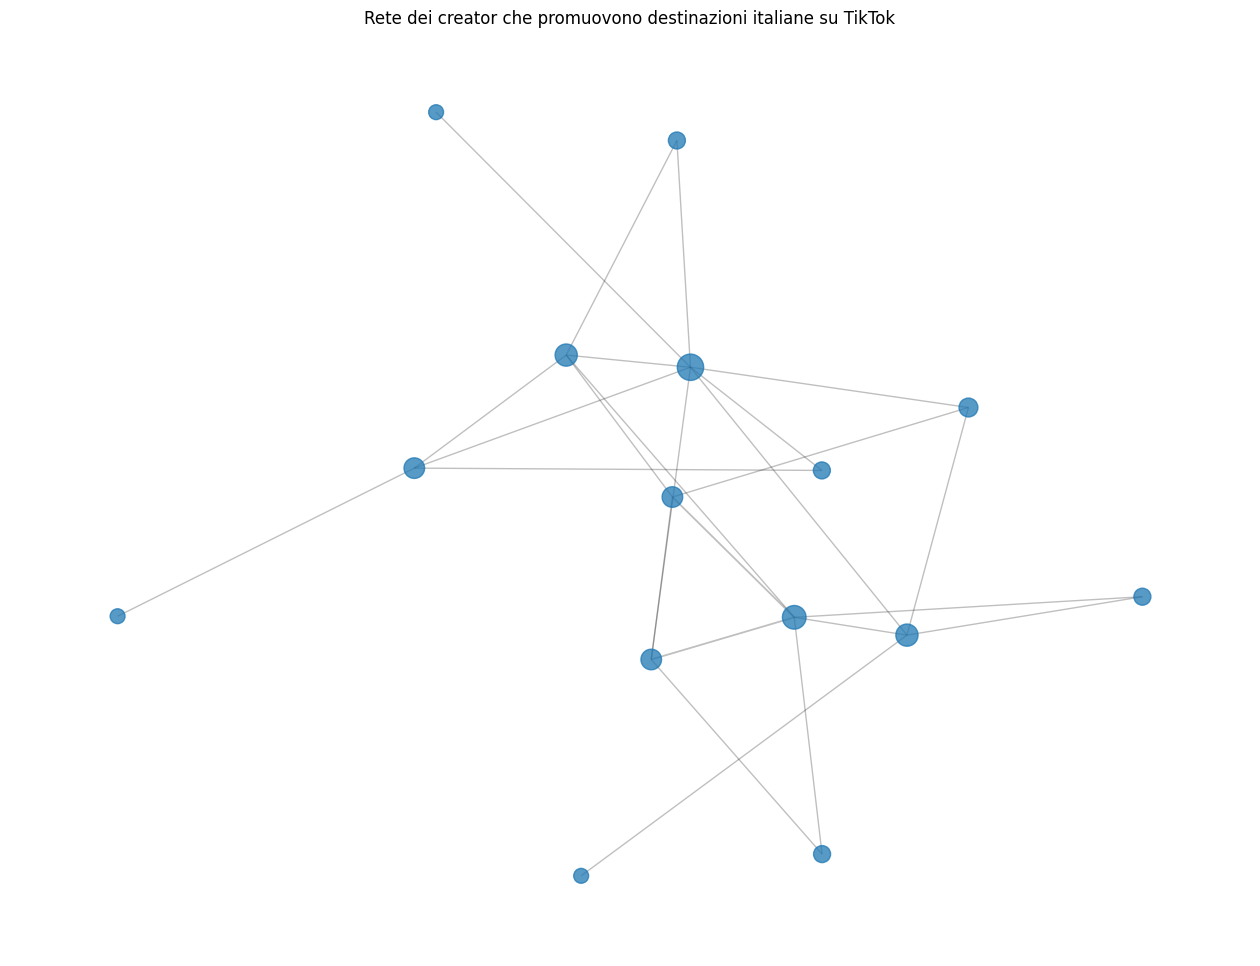

In [25]:
plt.figure(figsize=(16, 12))

position = nx.spring_layout(
    G_lcc,
    seed=42,
    k=1.2
)

degrees = dict(G_lcc.degree())

node_sizes = [
    80 + degrees[node] * 35
    for node in G_lcc.nodes()
]

edge_widths = [
    0.4 + G_lcc[u][v]["weight"] * 0.3
    for u, v in G_lcc.edges()
]

nx.draw_networkx_nodes(
    G_lcc,
    position,
    node_size=node_sizes,
    alpha=0.75
)

nx.draw_networkx_edges(
    G_lcc,
    position,
    width=edge_widths,
    alpha=0.25
)

plt.title(
    "Rete dei creator che promuovono "
    "destinazioni italiane su TikTok"
)

plt.axis("off")
plt.show()

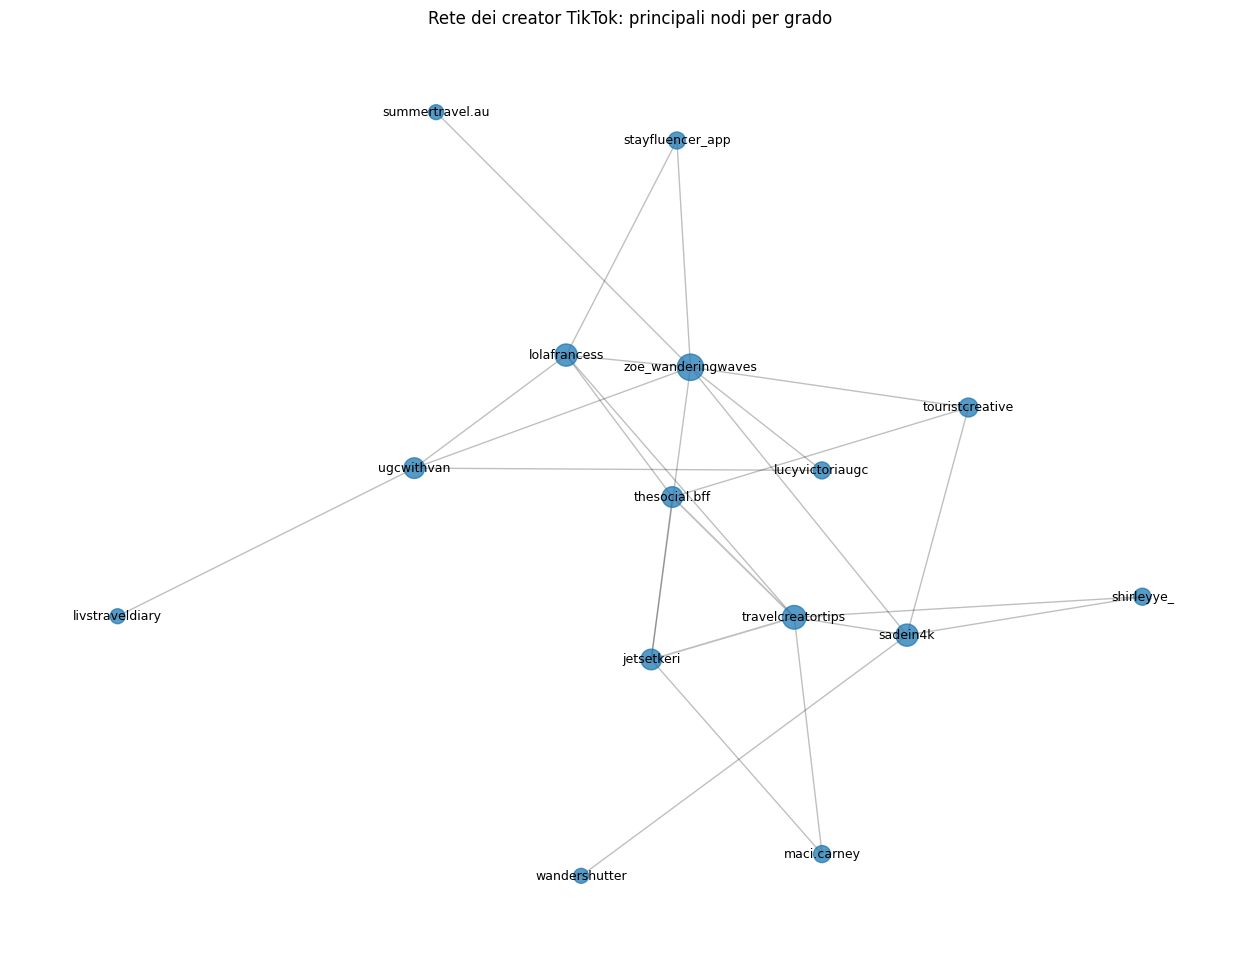

In [26]:
top_nodes = sorted(
    G_lcc.degree(),
    key=lambda item: item[1],
    reverse=True
)[:15]

top_node_names = [
    node
    for node, degree in top_nodes
]

labels = {
    node: node
    for node in top_node_names
}

plt.figure(figsize=(16, 12))

nx.draw_networkx_nodes(
    G_lcc,
    position,
    node_size=node_sizes,
    alpha=0.75
)

nx.draw_networkx_edges(
    G_lcc,
    position,
    width=edge_widths,
    alpha=0.25
)

nx.draw_networkx_labels(
    G_lcc,
    position,
    labels=labels,
    font_size=9
)

plt.title(
    "Rete dei creator TikTok: "
    "principali nodi per grado"
)

plt.axis("off")
plt.show()

## Costruzione della rete dei creator

La rete costruita è un grafo semplice, non orientato e pesato.

Ogni nodo rappresenta un creator TikTok che ha pubblicato almeno un
video relativo alla promozione di destinazioni turistiche italiane.

Due creator sono collegati quando utilizzano almeno due hashtag
informativi in comune. Il peso dell'arco corrisponde al numero di
hashtag condivisi.

Prima della costruzione della rete sono stati rimossi gli hashtag
troppo generici e gli hashtag utilizzati come punto di partenza
durante la raccolta dei dati. Questa procedura evita di creare
connessioni artificiali dovute al metodo di campionamento.

La rete rappresenta una relazione di similarità tematica tra i
creator e non necessariamente una collaborazione o una conoscenza
diretta tra essi.

In [27]:
degree_centrality = nx.degree_centrality(G_lcc)

degree_df = pd.DataFrame({
    "creator": list(degree_centrality.keys()),
    "degree_centrality": list(degree_centrality.values())
})

degree_df = degree_df.sort_values(
    "degree_centrality",
    ascending=False
)

degree_df.head(10)

,creator,degree_centrality
0,zoe_wanderingwaves,0.571429
7,travelcreatortips,0.428571
8,lolafrancess,0.357143
10,sadein4k,0.357143
14,jetsetkeri,0.285714
3,thesocial.bff,0.285714
13,ugcwithvan,0.285714
4,touristcreative,0.214286
9,maci.carney,0.142857
1,shirleyye_,0.142857


In [28]:
weighted_degree = dict(
    G_lcc.degree(weight="weight")
)

weighted_degree_df = pd.DataFrame({
    "creator": list(weighted_degree.keys()),
    "weighted_degree": list(weighted_degree.values())
})

weighted_degree_df = weighted_degree_df.sort_values(
    "weighted_degree",
    ascending=False
)

weighted_degree_df.head(10)

,creator,weighted_degree
0,zoe_wanderingwaves,16
7,travelcreatortips,14
8,lolafrancess,10
10,sadein4k,10
14,jetsetkeri,9
3,thesocial.bff,9
13,ugcwithvan,8
4,touristcreative,6
9,maci.carney,4
1,shirleyye_,4


In [29]:
betweenness_centrality = nx.betweenness_centrality(
    G_lcc,
    weight=None,
    normalized=True
)

betweenness_df = pd.DataFrame({
    "creator": list(betweenness_centrality.keys()),
    "betweenness": list(betweenness_centrality.values())
})

betweenness_df = betweenness_df.sort_values(
    "betweenness",
    ascending=False
)

betweenness_df.head(10)

,creator,betweenness
0,zoe_wanderingwaves,0.456960
10,sadein4k,0.221612
7,travelcreatortips,0.157509
13,ugcwithvan,0.153846
8,lolafrancess,0.135531
14,jetsetkeri,0.080586
3,thesocial.bff,0.025641
4,touristcreative,0.021062
5,summertravel.au,0.000000
1,shirleyye_,0.000000


In [30]:
closeness_centrality = nx.closeness_centrality(G_lcc)

closeness_df = pd.DataFrame({
    "creator": list(closeness_centrality.keys()),
    "closeness": list(closeness_centrality.values())
})

closeness_df = closeness_df.sort_values(
    "closeness",
    ascending=False
)

closeness_df.head(10)

,creator,closeness
0,zoe_wanderingwaves,0.700000
10,sadein4k,0.583333
8,lolafrancess,0.583333
7,travelcreatortips,0.560000
14,jetsetkeri,0.538462
4,touristcreative,0.518519
13,ugcwithvan,0.518519
3,thesocial.bff,0.500000
12,stayfluencer_app,0.466667
6,lucyvictoriaugc,0.451613


In [31]:
pagerank = nx.pagerank(
    G_lcc,
    weight="weight"
)

pagerank_df = pd.DataFrame({
    "creator": list(pagerank.keys()),
    "pagerank": list(pagerank.values())
})

pagerank_df = pagerank_df.sort_values(
    "pagerank",
    ascending=False
)

pagerank_df.head(10)

,creator,pagerank
0,zoe_wanderingwaves,0.148510
7,travelcreatortips,0.120929
10,sadein4k,0.096539
8,lolafrancess,0.090467
13,ugcwithvan,0.083143
14,jetsetkeri,0.079524
3,thesocial.bff,0.078587
4,touristcreative,0.057035
6,lucyvictoriaugc,0.043447
12,stayfluencer_app,0.041159


In [32]:
centrality_df = pd.DataFrame({
    "creator": list(G_lcc.nodes()),
    "degree": [
        G_lcc.degree(node)
        for node in G_lcc.nodes()
    ],
    "weighted_degree": [
        G_lcc.degree(node, weight="weight")
        for node in G_lcc.nodes()
    ],
    "degree_centrality": [
        degree_centrality[node]
        for node in G_lcc.nodes()
    ],
    "betweenness": [
        betweenness_centrality[node]
        for node in G_lcc.nodes()
    ],
    "closeness": [
        closeness_centrality[node]
        for node in G_lcc.nodes()
    ],
    "pagerank": [
        pagerank[node]
        for node in G_lcc.nodes()
    ],
    "followers": [
        G_lcc.nodes[node]["followers"]
        for node in G_lcc.nodes()
    ],
    "total_views": [
        G_lcc.nodes[node]["total_views"]
        for node in G_lcc.nodes()
    ]
})

centrality_df.sort_values(
    "pagerank",
    ascending=False
).head(15)

,creator,degree,weighted_degree,degree_centrality,betweenness,closeness,pagerank,followers,total_views
0,zoe_wanderingwaves,8,16,0.571429,0.456960,0.700000,0.148510,11500,16700
7,travelcreatortips,6,14,0.428571,0.157509,0.560000,0.120929,13200,469400
10,sadein4k,5,10,0.357143,0.221612,0.583333,0.096539,6152,10800
8,lolafrancess,5,10,0.357143,0.135531,0.583333,0.090467,17700,126300
13,ugcwithvan,4,8,0.285714,0.153846,0.518519,0.083143,9828,2091
14,jetsetkeri,4,9,0.285714,0.080586,0.538462,0.079524,57800,130202
3,thesocial.bff,4,9,0.285714,0.025641,0.500000,0.078587,73300,304800
4,touristcreative,3,6,0.214286,0.021062,0.518519,0.057035,3593,62000
6,lucyvictoriaugc,2,4,0.142857,0.000000,0.451613,0.043447,10500,125900
12,stayfluencer_app,2,4,0.142857,0.000000,0.466667,0.041159,334,67100


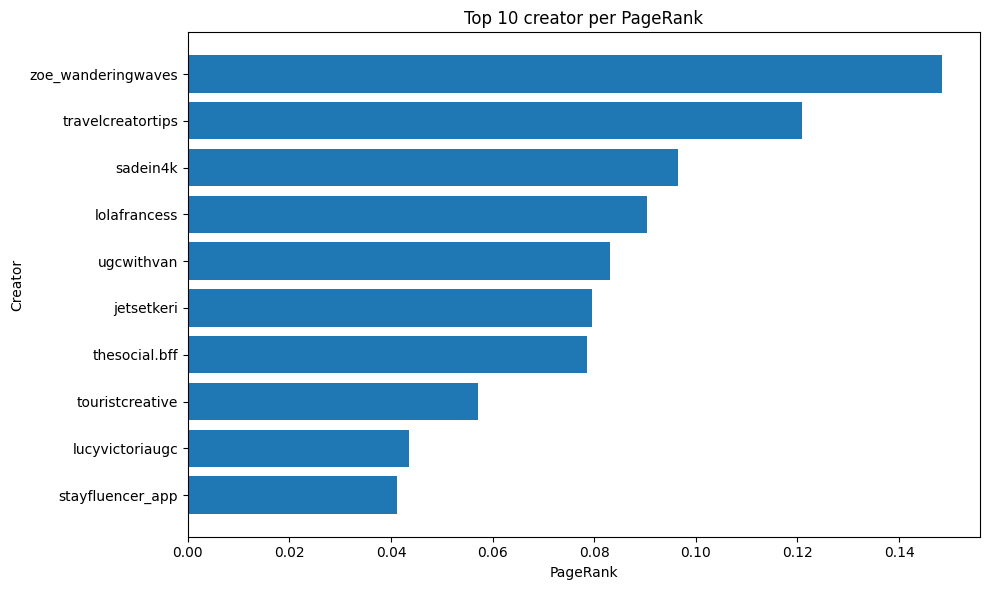

In [33]:
top_pagerank = centrality_df.sort_values(
    "pagerank",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_pagerank["creator"],
    top_pagerank["pagerank"]
)

plt.title("Top 10 creator per PageRank")
plt.xlabel("PageRank")
plt.ylabel("Creator")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

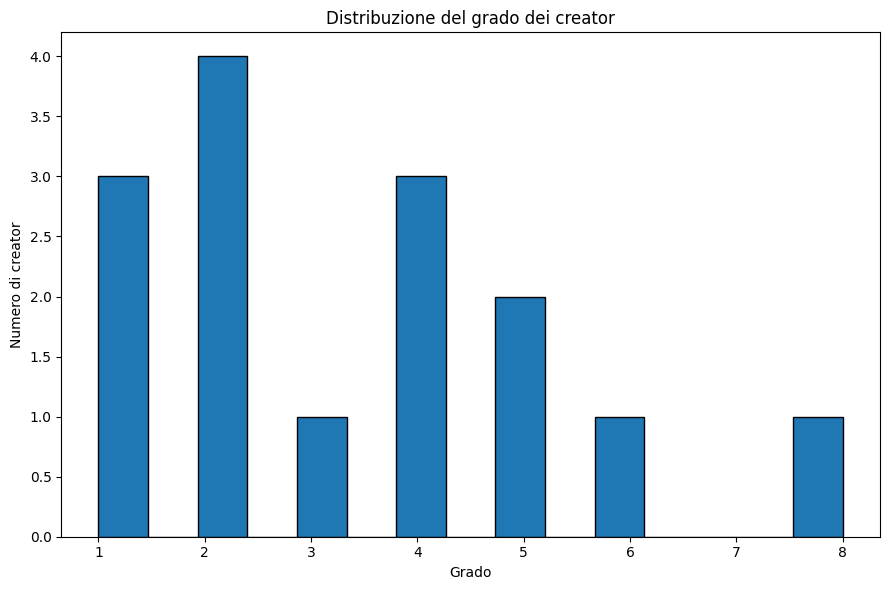

In [34]:
degrees_list = [
    degree
    for node, degree in G_lcc.degree()
]

plt.figure(figsize=(9, 6))

plt.hist(
    degrees_list,
    bins=15,
    edgecolor="black"
)

plt.title("Distribuzione del grado dei creator")
plt.xlabel("Grado")
plt.ylabel("Numero di creator")
plt.tight_layout()
plt.show()

In [35]:
partition = community_louvain.best_partition(
    G_lcc,
    weight="weight"
)

print("Numero community:", len(set(partition.values())))

Numero community: 3


In [36]:
community_df = pd.DataFrame({

    "creator": list(partition.keys()),

    "community": list(partition.values())

})

community_df.head()

,creator,community
0,zoe_wanderingwaves,0
1,shirleyye_,1
2,wandershutter,1
3,thesocial.bff,2
4,touristcreative,1


In [37]:
community_sizes = (
    community_df["community"]
    .value_counts()
    .sort_index()
)

community_sizes

,count
community,
0,7
1,4
2,4


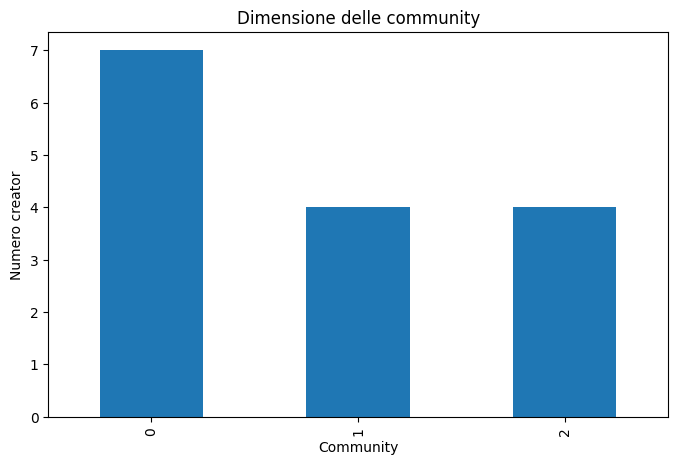

In [38]:
plt.figure(figsize=(8,5))

community_sizes.plot(
    kind="bar"
)

plt.title("Dimensione delle community")

plt.xlabel("Community")

plt.ylabel("Numero creator")

plt.show()

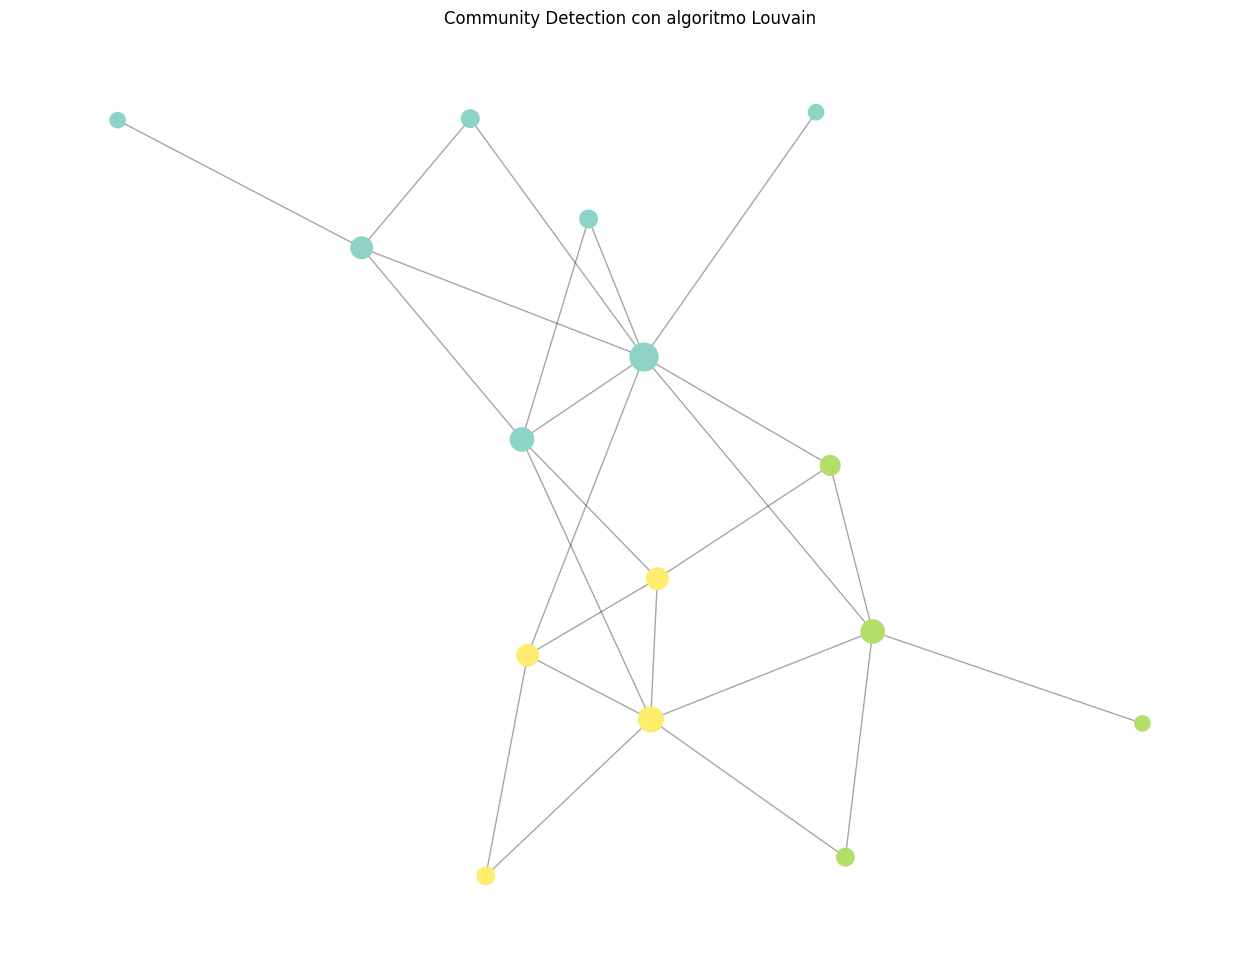

In [39]:
plt.figure(figsize=(16,12))

pos = nx.spring_layout(
    G_lcc,
    seed=42
)

colors = [
    partition[node]
    for node in G_lcc.nodes()
]

sizes = [
    80+G_lcc.degree(node)*40
    for node in G_lcc.nodes()
]

nx.draw_networkx_nodes(

    G_lcc,

    pos,

    node_color=colors,

    node_size=sizes,

    cmap=plt.cm.Set3

)

nx.draw_networkx_edges(

    G_lcc,

    pos,

    alpha=0.35

)

plt.title("Community Detection con algoritmo Louvain")

plt.axis("off")

plt.show()

In [40]:
centrality_with_community = centrality_df.copy()

centrality_with_community["community"] = (
    centrality_with_community["creator"].map(partition)
)

centrality_with_community.head()

,creator,degree,weighted_degree,degree_centrality,betweenness,closeness,pagerank,followers,total_views,community
0,zoe_wanderingwaves,8,16,0.571429,0.456960,0.700000,0.148510,11500,16700,0
1,shirleyye_,2,4,0.142857,0.000000,0.437500,0.041096,176100,298400,1
2,wandershutter,1,2,0.071429,0.000000,0.378378,0.026411,13100,14400,1
3,thesocial.bff,4,9,0.285714,0.025641,0.500000,0.078587,73300,304800,2
4,touristcreative,3,6,0.214286,0.021062,0.518519,0.057035,3593,62000,1


In [41]:
for community_id in sorted(
    centrality_with_community["community"].dropna().unique()
):

    print("\n" + "=" * 60)
    print(f"COMMUNITY {int(community_id)}")

    selected_rows = centrality_with_community[
        centrality_with_community["community"] == community_id
    ].sort_values(
        by="pagerank",
        ascending=False
    )

    display(
        selected_rows[
            [
                "creator",
                "pagerank",
                "followers",
                "degree",
                "weighted_degree",
                "betweenness",
                "total_views"
            ]
        ]
    )


COMMUNITY 0


,creator,pagerank,followers,degree,weighted_degree,betweenness,total_views
0,zoe_wanderingwaves,0.148510,11500,8,16,0.456960,16700
8,lolafrancess,0.090467,17700,5,10,0.135531,126300
13,ugcwithvan,0.083143,9828,4,8,0.153846,2091
6,lucyvictoriaugc,0.043447,10500,2,4,0.000000,125900
12,stayfluencer_app,0.041159,334,2,4,0.000000,67100
11,livstraveldiary,0.027667,10900,1,2,0.000000,2498
5,summertravel.au,0.025779,782,1,2,0.000000,4307



COMMUNITY 1


,creator,pagerank,followers,degree,weighted_degree,betweenness,total_views
10,sadein4k,0.096539,6152,5,10,0.221612,10800
4,touristcreative,0.057035,3593,3,6,0.021062,62000
1,shirleyye_,0.041096,176100,2,4,0.000000,298400
2,wandershutter,0.026411,13100,1,2,0.000000,14400



COMMUNITY 2


,creator,pagerank,followers,degree,weighted_degree,betweenness,total_views
7,travelcreatortips,0.120929,13200,6,14,0.157509,469400
14,jetsetkeri,0.079524,57800,4,9,0.080586,130202
3,thesocial.bff,0.078587,73300,4,9,0.025641,304800
9,maci.carney,0.039705,22900,2,4,0.000000,28600


In [42]:
print("Numero nodi:", G_lcc.number_of_nodes())
print("Numero archi:", G_lcc.number_of_edges())

print("Densità:", nx.density(G_lcc))

print("Clustering medio:",
      nx.average_clustering(G_lcc))

print("Grado medio:",
      sum(dict(G_lcc.degree()).values())/G_lcc.number_of_nodes())

Numero nodi: 15
Numero archi: 25
Densità: 0.23809523809523808
Clustering medio: 0.41619047619047617
Grado medio: 3.3333333333333335


In [43]:
print("Diametro:",
      nx.diameter(G_lcc))

Diametro: 4


In [44]:
print("Average shortest path:",
      nx.average_shortest_path_length(G_lcc))

Average shortest path: 2.085714285714286


In [45]:
eigen = nx.eigenvector_centrality(
    G_lcc,
    max_iter=1000
)

eigen_df = pd.DataFrame({

    "creator":eigen.keys(),

    "eigenvector":eigen.values()

})

eigen_df.sort_values(
    "eigenvector",
    ascending=False
).head(10)

,creator,eigenvector
0,zoe_wanderingwaves,0.449774
7,travelcreatortips,0.372165
8,lolafrancess,0.364923
10,sadein4k,0.304672
3,thesocial.bff,0.301230
14,jetsetkeri,0.300281
4,touristcreative,0.247498
13,ugcwithvan,0.242368
12,stayfluencer_app,0.191002
6,lucyvictoriaugc,0.162270


In [46]:
nx.degree_assortativity_coefficient(G_lcc)

-0.40630938806537514

In [47]:
centrality_df["followers"].corr(
    centrality_df["pagerank"]
)

centrality_df["followers"].corr(
    centrality_df["degree"]
)

np.float64(-0.08826736703846945)

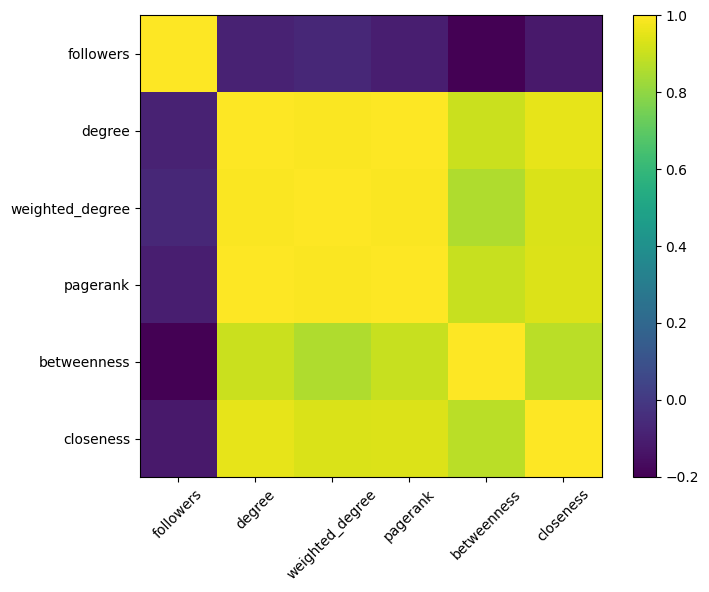

In [48]:
import matplotlib.pyplot as plt

corr = centrality_df[
    [
        "followers",
        "degree",
        "weighted_degree",
        "pagerank",
        "betweenness",
        "closeness"
    ]
].corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.show()

In [49]:
print(len(data))

240


"L'analisi della rete mostra che la community dei travel creator non è omogenea, ma si organizza in tre cluster principali. Alcuni creator assumono un ruolo centrale fungendo da ponte tra gruppi differenti. Inoltre, il numero di follower non coincide necessariamente con la centralità nella rete, suggerendo che la visibilità di un creator non dipende esclusivamente dalla sua popolarità ma anche dalla posizione strutturale nella rete."